# IMDB Dataset


In [1]:
#Importações


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.base import clone

#Importando nltk para manipular os textos e importando os módulos necessários.
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')

import time # usei para me auxiliar a descobrir o tempo de treino de cada modelo.

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [2]:
df = pd.read_csv(
    'IMDBDataset.csv',
    engine='python',
    on_bad_lines='skip'
)

In [3]:
df.shape

(50000, 2)

In [4]:
df.head(4)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [6]:
#Renomeando a coluna de sentimentos
df = df.rename(columns={'sentiment;;;;;;': 'sentiment'})

In [7]:
df['sentiment'].value_counts(normalize=True)

,proportion
sentiment,
positive,0.5
negative,0.5


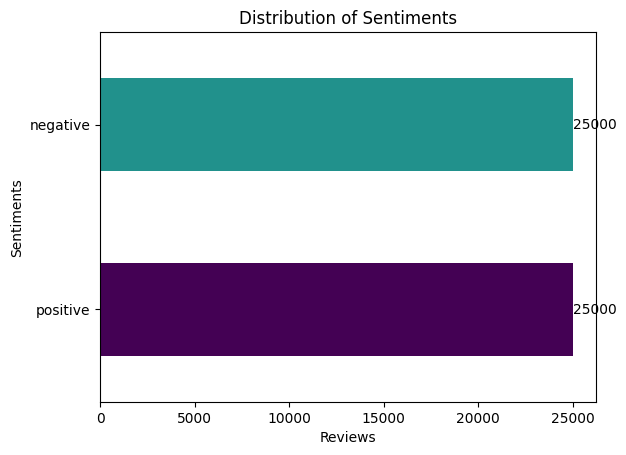

In [8]:
ax = df['sentiment'].value_counts().plot(kind='barh', color=['#440154', '#21918c'])

#Rótulos nas barras
for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribution of Sentiments')
plt.xlabel("Reviews")
plt.ylabel("Sentiments")
plt.show()

Percebe-se que há um equilíbrio na distribuição de sentimentos. 50% deles são positivos, enquanto os outros 50% são negativos, balanceando as classes.

# Comparação entre os modelos
Vou usar os seguintes modelos:
1. Random Forest
2. LGBM
3. XGBoost
4. Logistic Regression

As métricas que vão me auxiliar com relação a qual modelo melhor atende às minhas necessidades são: Acurácia, Recall, Precisão e F1Score.

# Transformação e Limpeza dos dados

Transformação dos valores da coluna "Sentiment"
Positivos = 1
Negativos = 0


In [9]:
df['sentiment'] = df['sentiment'].replace({
    'positive': 1,
    'negative': 0
})

/tmp/ipykernel_1305/2969472576.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sentiment'] = df['sentiment'].replace({


Limpeza de dados

In [10]:
#Preenchendo os valores vazios:

df['review'] = df['review'].fillna('')

In [11]:
#Criando a função de limpar texto

def limpar_texto(texto):
    texto = texto.lower()


    texto = re.sub(r'<.*?>', ' ', texto) #coloquei para limpar as tags htmls, porque ao analisar os bigramas, algumas tags do html, como a tag <br> estava retornando nas palavras analisadas.

    texto = re.sub(r'https?://\s+|www\.\S+', '', texto)

    texto = re.sub(r'[^a-zA-Z\s]', '', texto)

    # Aqui eu estou separando a string em uma lista de palavras
    tokens = word_tokenize(texto)

    palavras_vazias = set(stopwords.words('english'))

    tokens_sem_stopwords = []
    #apelidei os itens dentro de token como "palavra"
    for palavra in tokens:
        if palavra not in palavras_vazias:
            tokens_sem_stopwords.append(palavra) # adicionando item a nova lista limpa

    stemmer = PorterStemmer()
    tokens_stemmed = []
    for palavra in tokens_sem_stopwords:
        tokens_stemmed.append(stemmer.stem(palavra))

    texto_limpo = " ".join(tokens_stemmed) # aq eu junto a lista de palavras novamente em uma única string

    return texto_limpo

# Variáveis de Teste e de Treino

In [ ]:
X = df['review'].apply(limpar_texto) #preditora
y = df['sentiment'] #predita - alvo


#Vou usar a proporção 70/30. 70% dos dados para treinamento e 30% para teste

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

print(f"Reviews separadas para Treino: {len(X_train)}")
print(f"Reviews separadas para Teste: {len(X_test)}")

Temos 35.000 reviews separadas para teste e 15.000 para treino.

#**Técnicas de vetorização**

**Bag of Words (BoW)**:
Representa os textos pela frequência das palavras, ignorando sua ordem.

**TF-IDF:**
Representa os textos atribuindo maior peso às palavras mais relevantes e menos frequentes no conjunto de documentos.

In [ ]:
#Cria o TF-IDF padrão para os modelos que dependem dele não criarem
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = tfidf_vectorizer.fit_transform(X_train)
X_test_vec = tfidf_vectorizer.transform(X_test)

#Cria o CountVectorizer (BoW)
bow_vectorizer = CountVectorizer(max_features=5000)

abordagens = {
    "TF-IDF": tfidf_vectorizer,
    "BoW": bow_vectorizer
}


# **Métricas**

**Análise das métricas:**
- Acurácia: Define a porcentagem de acerto das previsões no total.
- Precision: Define a porcentagem de acerto quando prevê positivo.
- Recall: Porcentagem de positivos reais encontrados pelo modelo.
- F1Score: média harmônica entre precisão e recall.
- AUC-ROC: avalia o desempenho de modelos de classificação binária. Ela mede a capacidade do modelo de distinguir entre duas classes, calculando a área sob a curva ROC. Quanto mais próximo de 1, melhor o modelo; quanto mais próximo de 0,5, pior.

# ***Algoritmos de Classificação***

**Logistic Regression:**
Modelo de classificação que estima a probabilidade de um texto pertencer a cada classe.

**Random Forest:**
Conjunto de árvores de decisão que classificam por votação.

**XGBoost:** Algoritmo de Gradient Boosting que corrige iterativamente os erros das árvores anteriores.

**LightGBM:**
Versão otimizada de Gradient Boosting, projetada para alta velocidade e eficiência.



# ***Modelo 1: Random Florest***

# Treino

In [ ]:
#Modelo
modelo = RandomForestClassifier(n_estimators=100, random_state=42)

#Treino
inicio = time.perf_counter()
modelo.fit(X_train_vec, y_train)
tempo_treino_rf = time.perf_counter() - inicio

#Previsões
inicio = time.perf_counter()
previsoes_rf = modelo.predict(X_test_vec)
tempo_pred_rf = time.perf_counter() - inicio

print(f"Random Forest - Treino: {tempo_treino_rf:.4f}s")
print(f"Random Forest - Predição: {tempo_pred_rf:.4f}s")


# Métricas de Avaliação:

In [ ]:
acuracia = accuracy_score(y_test, previsoes_rf)
print(f" Acurácia Geral: {acuracia:.2%}\n")

probabilidades = modelo.predict_proba(X_test_vec)[:, 1]

auc_score = roc_auc_score(y_test, probabilidades)
print(f"Valor do AUC-ROC: {auc_score:.4f}\n")

print("Demais métricas:")
cr = classification_report(y_test, previsoes_rf)
print(cr)


print("Matriz de Confusão:")
mc = confusion_matrix(y_test, previsoes_rf)
print(mc)



# ***Modelo 2: LGBM***

# Treino

In [ ]:
# Modelo LightGBM
modelo_lgbm = LGBMClassifier(n_estimators=200, learning_rate=0.1, random_state=42)

# Treino
inicio = time.perf_counter()
modelo_lgbm.fit(X_train_vec, y_train)
tempo_treino_lgbm = time.perf_counter() - inicio

# Previsão
inicio = time.perf_counter()
previsoes_lgbm = modelo_lgbm.predict(X_test_vec)
tempo_pred_lgbm = time.perf_counter() - inicio


print(f"LGBM - Treino: {tempo_treino_rf:.4f}s")
print(f"LGBM - Predição: {tempo_pred_rf:.4f}s")


# Métricas de Avaliação

In [ ]:

acuracia = accuracy_score(y_test, previsoes_lgbm)
print(f" Acurácia Geral: {acuracia:.2%}\n")

probabilidades = modelo_lgbm.predict_proba(X_test_vec)[:, 1]

auc_score = roc_auc_score(y_test, probabilidades)
print(f"Valor do AUC-ROC: {auc_score:.4f}\n")

print("Demais métricas:")
cr = classification_report(y_test, previsoes_lgbm)
print(cr)

print("Matriz de Confusão:")
mc = confusion_matrix(y_test, previsoes_lgbm)
print(mc)

# ***Modelo 3: XGBoost***

# Treino

In [ ]:
#esse encoder é só para o xgb
le = LabelEncoder()
y_train_xgb = le.fit_transform(y_train)

#Definição do modelo
modelo_xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss'
)

#Treino
inicio = time.perf_counter()
modelo_xgb.fit(X_train_vec, y_train_xgb)
tempo_treino_xgb = time.perf_counter() - inicio

#Previsão
inicio = time.perf_counter()
previsoes_xgb = modelo_xgb.predict(X_test_vec)
tempo_pred_xgb = time.perf_counter() - inicio


#Mantendo o mesmo formaatos dos outros modelos:
previsoes_xgb = le.inverse_transform(previsoes_xgb)


print(f"XGBoost - Treino: {tempo_treino_rf:.4f}s")
print(f"XGBoost - Predição: {tempo_pred_rf:.4f}s")

# Métricas de Avaliação

In [ ]:
acuracia = accuracy_score(y_test, previsoes_xgb)
print(f" Acurácia Geral: {acuracia:.2%}\n")

probabilidades = modelo_xgb.predict_proba(X_test_vec)[:, 1]

auc_score = roc_auc_score(y_test, probabilidades)
print(f"Valor do AUC-ROC: {auc_score:.4f}\n")

print("Demais métricas:")
cr = classification_report(y_test, previsoes_xgb)
print(cr)

print("Matriz de Confusão:")
mc = confusion_matrix(y_test, previsoes_xgb)
print(mc)

# ***Modelo 4: Logistic Regression***

# Treino

In [ ]:

#Modelo
modelo_lr = LogisticRegression(random_state=42)

#Treino
inicio = time.perf_counter()
modelo_lr.fit(X_train_vec, y_train)
tempo_treino_lr = time.perf_counter() - inicio

#previsão
inicio = time.perf_counter()
previsoes_lr = modelo_lr.predict(X_test_vec)
tempo_pred_lr = time.perf_counter() - inicio


print(f"Logistic Regression - Treino: {tempo_treino_rf:.4f}s")
print(f"Logistic Regression - Predição: {tempo_pred_rf:.4f}s")

#  Métricas de Avaliação

In [ ]:
acuracia = accuracy_score(y_test, previsoes_lr)
print(f" Acurácia Geral: {acuracia:.2%}\n")

probabilidades = modelo_lr.predict_proba(X_test_vec)[:, 1]

auc_score = roc_auc_score(y_test, probabilidades)
print(f"Valor do AUC-ROC: {auc_score:.4f}\n")

print("Demais métricas:")
cr = classification_report(y_test, previsoes_lr)
print(cr)

print("Matriz de Confusão:")
mc = confusion_matrix(y_test, previsoes_lr)
print(mc)

## **Avaliação Comparativa dos Modelos com TF-IDF e BoW.**

In [ ]:
modelos_vs = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        random_state=42,
        force_row_wise=True,
        verbose=-1
    ),
    "XGBoost": XGBClassifier(
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
        verbosity=0
    ),
    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000,
        n_jobs=-1
    )
}

todos_resultados = []

for nome_abordagem, vectorizer in abordagens.items():
    print(f"Processando abordagem: {nome_abordagem}...")

    X_train_vec_atual = vectorizer.fit_transform(X_train).astype("float32")
    X_test_vec_atual = vectorizer.transform(X_test).astype("float32")

    for nome_modelo, mdl in modelos_vs.items():
        print(f"  Treinando modelo: {nome_modelo} com {nome_abordagem}...")
        modelo_atual = clone(mdl)

        if nome_modelo == "XGBoost":
            y_train_fit = y_train_xgb
        else:
            y_train_fit = y_train

        inicio_treino = time.perf_counter()
        modelo_atual.fit(X_train_vec_atual, y_train_fit)
        tempo_treino = time.perf_counter() - inicio_treino

        inicio_pred = time.perf_counter()
        previsao = modelo_atual.predict(X_test_vec_atual)
        tempo_pred = time.perf_counter() - inicio_pred

        if nome_modelo == "XGBoost":
            previsao = le.inverse_transform(previsao)

        probabilidades = modelo_atual.predict_proba(X_test_vec_atual)[:, 1]

        acuracia = accuracy_score(y_test, previsao)
        auc_score = roc_auc_score(y_test, probabilidades)
        cr = classification_report(y_test, previsao, output_dict=True)

        todos_resultados.append({
            "Experiment": f"{nome_modelo} ({nome_abordagem})",
            "Accuracy": acuracia,
            "AUC-ROC": auc_score,
            "Precision": cr["weighted avg"]["precision"],
            "Recall": cr["weighted avg"]["recall"],
            "F1-Score": cr["weighted avg"]["f1-score"],
            "Training time (s)": tempo_treino,
            "Prediction time (s)": tempo_pred
        })

df_metricas_vs = pd.DataFrame(todos_resultados)

df_p_vs = df_metricas_vs.copy().astype(object)

for col in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    df_p_vs[col] = df_p_vs[col].apply(lambda x: f"{x:.2%}")

df_p_vs["AUC-ROC"] = df_p_vs["AUC-ROC"].apply(lambda x: f"{x:.4f}")
df_p_vs["Training time (s)"] = df_p_vs["Training time (s)"].apply(lambda x: f"{x:.2f}")
df_p_vs["Prediction time (s)"] = df_p_vs["Prediction time (s)"].apply(lambda x: f"{x:.2f}")

fig, ax = plt.subplots(figsize=(20, 9))
ax.axis("off")

tab = ax.table(cellText=df_p_vs.values, colLabels=df_p_vs.columns, loc="center", cellLoc="center")

tab.set_fontsize(14)
tab.scale(1.4, 2.8)

for j in range(len(df_p_vs.columns)):
    tab[0, j].set_text_props(weight="bold", color="white", fontsize=15)
    tab[0, j].set_facecolor("#2C3E50")

plt.savefig("comparativo_tfidf_vs_bow.png", dpi=350, bbox_inches="tight")
plt.show()

Com base na matriz abaixo, é possível concluir que o modelo de classificação de Regressão Logística, utilizando como vetorizador o TF-IDF é o que obteve as melhores métricas.

Tempo de processamento de treino e de predição para cada modelo.

# **AUC-ROC**

In [ ]:
plt.figure(figsize=(10,8))

# Random Forest
proba_rf = modelo.predict_proba(X_test_vec)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, proba_rf)
auc_rf = roc_auc_score(y_test, proba_rf)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC = {auc_rf:.4f})'
)

# LightGBM
proba_lgbm = modelo_lgbm.predict_proba(X_test_vec)[:,1]
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, proba_lgbm)
auc_lgbm = roc_auc_score(y_test, proba_lgbm)

plt.plot(
    fpr_lgbm,
    tpr_lgbm,
    label=f'LightGBM (AUC = {auc_lgbm:.4f})'
)

# XGBoost
proba_xgb = modelo_xgb.predict_proba(X_test_vec)[:,1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, proba_xgb)
auc_xgb = roc_auc_score(y_test, proba_xgb)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f'XGBoost (AUC = {auc_xgb:.4f})'
)

# Logistic Regression
proba_lr = modelo_lr.predict_proba(X_test_vec)[:,1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, proba_lr)
auc_lr = roc_auc_score(y_test, proba_lr)

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f'Logistic Regression (AUC = {auc_lr:.4f})'
)


plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True positive rate (TPR)')
plt.title('Comparison of the curves ROC')
plt.legend(loc='lower right')
plt.grid(True)

plt.show()

Todos os modelos apresentam uma taxa boa, com base na curva AUC-ROC, sendo que o modelo **'Logistic Regression'** apresentou a melhor taxa, **0.9539.**, seguido de:

**LightGBM --> 0.9456**

**XGBoost --> 0.9328**

**Random Forest --> 0.9254**



# Encontrando os bigramas mais comuns

In [ ]:
#Separando reviews positivas e negativaS
reviews_positivas = X[y == 1]
reviews_negativas = X[y == 0]

#Função para extrair bigramas mais comuns
def bigramas_mais_comuns(textos, top_n=20):
    vectorizer = CountVectorizer(
        ngram_range=(2, 2),
        max_features=5000
    )

    matriz_bigramas = vectorizer.fit_transform(textos)

    soma_bigramas = matriz_bigramas.sum(axis=0)

    frequencias = [
        (bigrama, soma_bigramas[0, idx])
        for bigrama, idx in vectorizer.vocabulary_.items()
    ]

    df_bigramas = pd.DataFrame(
        frequencias,
        columns=["Bigrama", "Frequência"]
    )

    df_bigramas = df_bigramas.sort_values(
        by="Frequência",
        ascending=False
    ).head(top_n)

    return df_bigramas

#Top 10 bigramas positivos
bigramas_positivos = bigramas_mais_comuns(reviews_positivas, top_n=10)

#Top 10 bigramas negativos
bigramas_negativos = bigramas_mais_comuns(reviews_negativas, top_n=10)

print("Bigramas mais comuns nas reviews positivas:")
display(bigramas_positivos)

print("Bigramas mais comuns nas reviews negativas:")
display(bigramas_negativos)

# Visualizando os bigramas


POSITIVOS

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=bigramas_positivos,
    x="Frequência",
    y="Bigrama",
    color="#21918c"
)

plt.title("Most common bigrams in positive reviews")
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.show()

NEGATIVOS

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=bigramas_negativos,
    x="Frequência",
    y="Bigrama",
    color="#440154"
)

plt.title("Most common bigrams in negative reviews")
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.show()